<a href="https://colab.research.google.com/github/jagadeeshsandopu/DEEP-NEURAL-NETWORK-FROM-SCRATCH/blob/main/ANN_FROM_SCRATCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## importing required libraries

import torch
import torchvision
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST,FashionMNIST
from torch.utils.data import DataLoader,random_split
from torchvision.transforms import ToTensor

# MNIST Dataset

In [ ]:
## loading MNIST Dataset

train_dataset = MNIST(root='data/',download=True,transform=ToTensor())
test_dataset = MNIST(root = 'data/',download=True,train=False,transform=ToTensor())

len(train_dataset),len(test_dataset)

(60000, 10000)

In [ ]:
train_ds,val_ds = random_split(train_dataset,[50000,10000])

len(train_ds),len(val_ds)

(50000, 10000)

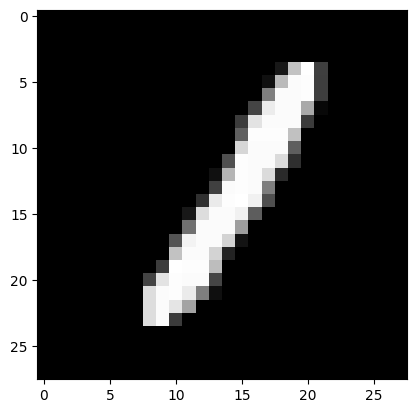


 
 Label: 1


In [ ]:
index = torch.randint(0,len(train_ds),size=(1,))
img,label = train_dataset[index.item()]

plt.imshow(img.reshape(28,28),cmap='gray')
plt.show()
print('\n \n Label: {}'.format(label))

In [ ]:
def preprocessing(img,label):

  reshaped_img = img.reshape(28*28,1).float()/255.0
  one_hot_label = F.one_hot(torch.tensor(label),num_classes = 10).reshape(10,1)

  return reshaped_img,one_hot_label

In [ ]:
class Base_Layer:

  def __init__(self):
    self.input = None
    self.output = None

  def forward_prop(self,input):
    pass

  def backward_prop(self,output_gradient,learning_rate):
    pass

In [ ]:
class Dense(Base_Layer):

  def __init__(self,input_size,output_size):
    super().__init__()
    self.weights = torch.rand((output_size,input_size))
    self.bias = torch.rand((output_size,1))

  def forward_prop(self,input):
    self.input = input
    return self.weights@input + self.bias

  def backward_prop(self,output_gradient,learning_rate):

    input_gradient = self.weights.T@output_gradient
    self.weights -= learning_rate*output_gradient@self.input.T
    self.bias -= learning_rate*output_gradient

    return input_gradient

In [ ]:
## Cross Entropy Loss

def cross_entropy_loss(y_pred,y_actual):
  return -1*torch.mean(y_actual*torch.log(y_pred))

def cross_entropy_loss_prime(y_pred,y_actual):
  return -1*(y_actual/y_pred)


In [ ]:
## Sigmoid Activation Layer

class Sigmoid(Base_Layer):

  def __init__(self):
    self.activation = torch.sigmoid
    self.activation_prime = lambda x: torch.sigmoid(x) * (1 - torch.sigmoid(x))


  def forward_prop(self,input):
    self.input = input
    return self.activation(input)

  def backward_prop(self,output_gradient,learning_rate):
    return output_gradient*self.activation_prime(self.input)



## Hyperbolic Tanh Activation Layer

class Tanh(Base_Layer):

  def __init__(self):
    self.activation = torch.tanh
    self.activation_prime = lambda x: 1 - torch.tanh(x)**2


  def forward_prop(self,input):
    self.input = input
    return self.activation(input)

  def backward_prop(self,output_gradient,learning_rate):
    return output_gradient*self.activation_prime(self.input)


  ## ReLU Activation Layer
class ReLU(Base_Layer):

  def __init__(self,alpha = 0.01):
    super().__init__()
    self.activation = torch.relu
    self.alpha = alpha

  def forward_prop(self,input):
    self.input = input
    return self.activation(input)

  def backward_prop(self,output_gradient,learning_rate):
   leaky_grad = torch.where(self.input > 0, 1.0, self.alpha)
   return output_gradient * leaky_grad


## Softmax Activation Layer

class Softmax(Base_Layer):

  def forward_prop(self,input):
    temp = torch.exp(input)
    self.output = temp/torch.sum(temp)
    return self.output

  def backward_prop(self,output_gradient,learning_rate):

    n = torch.numel(self.output)
    temp = (torch.eye(n) - self.output.T) * self.output
    return temp @ output_gradient

In [ ]:
def calculate_accuracy(dataset,network):

  correct = 0
  prob = 0

  for img,digit in dataset:

    img,label = preprocessing(img,digit)

    input = img

    for layer in network:
      input = layer.forward_prop(input)

    probability,digit_pred = torch.max(input,dim=0)

    if digit_pred.item() == digit:
      correct+=1
      prob+=probability.item()

    accuracy = correct/len(dataset)

  return round(accuracy*100,2)

In [ ]:
epochs = 30
learning_rate = 0.05
network = [Dense(784,50),ReLU(),Dense(50,10),Softmax()]

In [ ]:
def training_loop(epochs,learning_rate,train_dataset,val_dataset,network):

 errors = []
 epochss = []

 for epoch in range(epochs):

   error = 0

   for img,label in train_dataset:

     img,label = preprocessing(img,label)
     output = img


     for layer in network:
       output = layer.forward_prop(output)


     error += cross_entropy_loss(output,label)

     output_gradient = cross_entropy_loss_prime(output,label)

     for layer in reversed(network):
       output_gradient = layer.backward_prop(output_gradient,learning_rate)


   val_accuracy = calculate_accuracy(val_dataset,network)

   error /= len(train_dataset)

   errors.append(error)
   epochss.append(epoch+1)

   print(f"Epoch {epoch} ------------------ Training Error {error.item()} ----------------- Validation Accuracy {val_accuracy}")

 return (epochss,errors)

In [ ]:
epochss,errors = training_loop(epochs,learning_rate,train_ds,val_ds,network)

Epoch 0 ------------------ Training Error 0.20092377066612244 ----------------- Validation Accuracy 38.37
Epoch 1 ------------------ Training Error 0.14535701274871826 ----------------- Validation Accuracy 57.01
Epoch 2 ------------------ Training Error 0.11287731677293777 ----------------- Validation Accuracy 67.41
Epoch 3 ------------------ Training Error 0.09762077033519745 ----------------- Validation Accuracy 75.79
Epoch 4 ------------------ Training Error 0.08784916251897812 ----------------- Validation Accuracy 79.78
Epoch 5 ------------------ Training Error 0.08162511140108109 ----------------- Validation Accuracy 80.06
Epoch 6 ------------------ Training Error 0.07694703340530396 ----------------- Validation Accuracy 79.66
Epoch 7 ------------------ Training Error 0.07350511103868484 ----------------- Validation Accuracy 79.88
Epoch 8 ------------------ Training Error 0.07046955078840256 ----------------- Validation Accuracy 81.61
Epoch 9 ------------------ Training Error 0.06

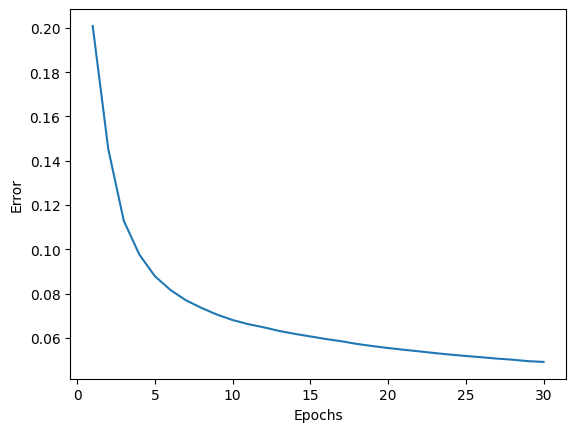

In [ ]:
plt.plot(epochss,errors)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

In [ ]:
test_accuracy = calculate_accuracy(test_dataset,network)

print(f"Accuracy on MNIST Test dataset is {test_accuracy}%")

Accuracy on MNIST Test dataset is 86.49%


# Fashion MNIST Dataset

In [ ]:
train_ds_fmnist = FashionMNIST(root='data/',download=True,transform=ToTensor())
test_ds_fmnist = FashionMNIST(root = 'data/',download=True,train=False,transform=ToTensor())

len(train_ds_fmnist), len(test_ds_fmnist)

(60000, 10000)

In [ ]:
train_ds_fmnist,val_ds_fmnist = random_split(train_ds_fmnist,[50000,10000])

In [ ]:
classes = test_ds_fmnist.classes
print(classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


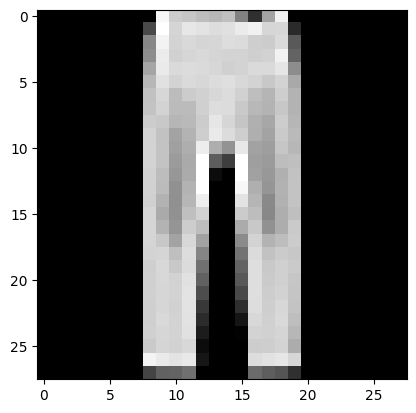


 
 Label: Trouser


In [ ]:
index = torch.randint(0,len(train_ds_fmnist),size=(1,))
img,label = train_ds_fmnist[index.item()]

plt.imshow(img.reshape(28,28),cmap='gray')
plt.show()
print('\n \n Label: {}'.format(classes[label]))

In [ ]:
epochs = 30
learning_rate = 0.05
network = [Dense(784,100),ReLU(),Dense(100,10),ReLU(),Softmax()]

In [ ]:
epochss,errors = training_loop(epochs,learning_rate,train_ds_fmnist,val_ds_fmnist,network)

Epoch 0 ------------------ Training Error 0.16041024029254913 ----------------- Validation Accuracy 42.53
Epoch 1 ------------------ Training Error 0.11750318109989166 ----------------- Validation Accuracy 48.19
Epoch 2 ------------------ Training Error 0.10372698307037354 ----------------- Validation Accuracy 51.22
Epoch 3 ------------------ Training Error 0.09621932357549667 ----------------- Validation Accuracy 56.23
Epoch 4 ------------------ Training Error 0.09129143506288528 ----------------- Validation Accuracy 62.37
Epoch 5 ------------------ Training Error 0.08824466168880463 ----------------- Validation Accuracy 64.62
Epoch 6 ------------------ Training Error 0.08599522709846497 ----------------- Validation Accuracy 66.76
Epoch 7 ------------------ Training Error 0.08397911489009857 ----------------- Validation Accuracy 68.62
Epoch 8 ------------------ Training Error 0.08237165212631226 ----------------- Validation Accuracy 69.56
Epoch 9 ------------------ Training Error 0.08

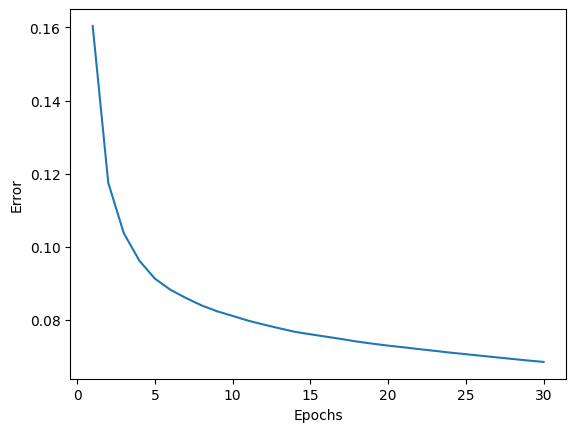

In [ ]:
plt.plot(epochss,errors)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

In [ ]:
test_accuracy = calculate_accuracy(test_ds_fmnist,network)

print(f"Accuracy on Fashion MNIST test dataset is {test_accuracy}%")

Accuracy on Fashion MNIST test dataset is 73.74%
